# Mathematical Models of the Chua Circuit and Rössler System
### Forward Euler Discretization and Q16.16 Fixed-Point Analysis

**Thesis:** FPGA Implementation of Chaos-Based Secure Communication Using Chua Circuit and Rössler System

This notebook documents:
1. The continuous-time mathematical models of the Chua circuit and Rössler system
2. Their Forward Euler discretization for digital/FPGA implementation
3. A fixed-point (Qm.n) precision sweep used to select the bit-width for the FPGA datapath
4. Comparison plots (phase portraits, time series, error metrics) justifying the chosen format


## 1. Chua Circuit

### 1.1 Continuous-time model

The dimensionless Chua circuit is described by the system of ODEs:

$$
\begin{aligned}
\dot{x} &= \alpha\,(y - x - f(x)) \\
\dot{y} &= x - y + z \\
\dot{z} &= -\beta y
\end{aligned}
$$

where $f(x)$ is the piecewise-linear **Chua diode** characteristic:

$$
f(x) = m_1 x + \tfrac{1}{2}(m_0 - m_1)\big(|x+1| - |x-1|\big)
$$

**Chaotic parameter set used:** $\alpha = 15.6$, $\beta = 28$, $m_0 = -1.143$, $m_1 = -0.714$

### 1.2 Forward Euler discretization

With step size $h$, each state variable is updated as:

$$
\begin{aligned}
x_{n+1} &= x_n + h\,\alpha\,(y_n - x_n - f(x_n)) \\
y_{n+1} &= y_n + h\,(x_n - y_n + z_n) \\
z_{n+1} &= z_n + h\,(-\beta y_n)
\end{aligned}
$$

This recurrence form is what gets implemented directly in HDL/HLS as the per-cycle update.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from chaos_models import (
    simulate_chua, simulate_rossler,
    simulate_chua_fixed, simulate_rossler_fixed,
    to_fixed, from_fixed, compare_precision,
)

N = 5000  # simulation steps
H = 0.001  # Euler step size


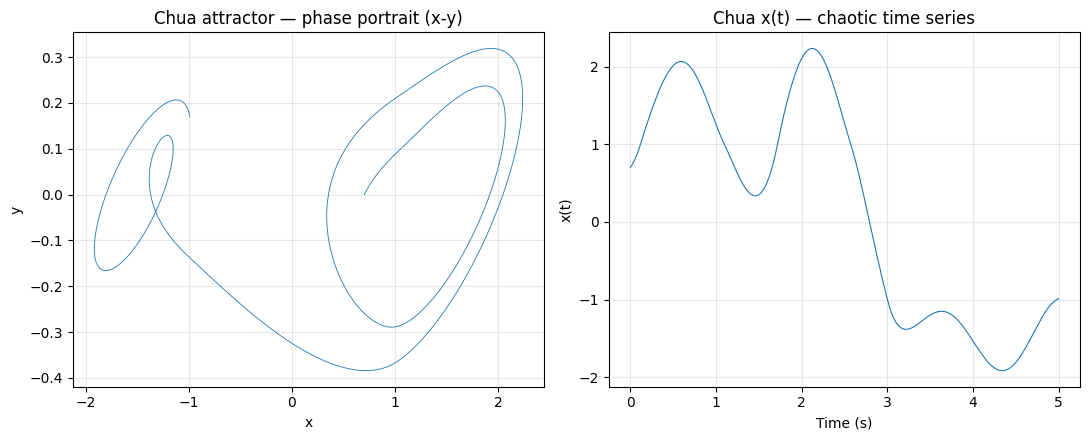

Final state (x,y,z): [-0.98975367  0.17037591  0.61370583]


In [2]:
# Floating-point reference simulation
chua_float = simulate_chua(N, h=H)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(chua_float[:, 0], chua_float[:, 1], lw=0.6)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("Chua attractor — phase portrait (x-y)")
axes[0].grid(alpha=0.3)

t = np.arange(N) * H
axes[1].plot(t, chua_float[:, 0], lw=0.8)
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("x(t)")
axes[1].set_title("Chua x(t) — chaotic time series")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Final state (x,y,z):", chua_float[-1])


## 2. Rössler System

### 2.1 Continuous-time model

$$
\begin{aligned}
\dot{x} &= -y - z \\
\dot{y} &= x + a y \\
\dot{z} &= b + z(x - c)
\end{aligned}
$$

**Chaotic parameter set used:** $a = 0.2$, $b = 0.2$, $c = 5.7$

### 2.2 Forward Euler discretization

$$
\begin{aligned}
x_{n+1} &= x_n + h\,(-y_n - z_n) \\
y_{n+1} &= y_n + h\,(x_n + a y_n) \\
z_{n+1} &= z_n + h\,(b + z_n(x_n - c))
\end{aligned}
$$


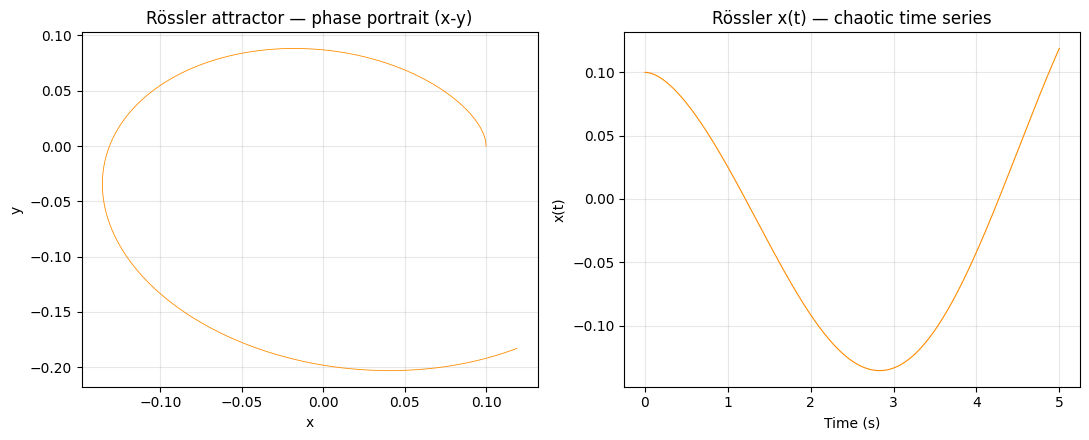

Final state (x,y,z): [ 0.11889143 -0.18301658  0.03565738]


In [3]:
rossler_float = simulate_rossler(N, h=H)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(rossler_float[:, 0], rossler_float[:, 1], lw=0.6, color="darkorange")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("Rössler attractor — phase portrait (x-y)")
axes[0].grid(alpha=0.3)

axes[1].plot(t, rossler_float[:, 0], lw=0.8, color="darkorange")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("x(t)")
axes[1].set_title("Rössler x(t) — chaotic time series")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Final state (x,y,z):", rossler_float[-1])


## 3. Fixed-Point (Qm.n) Representation

For FPGA implementation, all real-valued quantities are represented as **signed fixed-point
integers** in Qm.n format:

- **Total word width:** $m + n + 1$ bits (1 sign bit, $m$ integer bits, $n$ fractional bits)
- **Value:** $\text{real value} = \dfrac{\text{integer representation}}{2^n}$
- Multiplication of two Qm.n numbers produces a Q(2m).(2n) result, which must be **right-shifted by
  $n$ bits** (with rounding/saturation) to return to Qm.n.

A 32-bit word is used throughout (matching standard FPGA register/DSP widths). The fractional
bit-width $n$ is the key design parameter — it trades off **dynamic range** (larger values
representable) against **precision** (smaller quantization step).

The cell below implements bit-accurate integer arithmetic emulating this fixed-point datapath,
including saturation on overflow — this directly mirrors what the HDL/HLS implementation does.


In [4]:
# Example: Q16.16 representation of a value
val = 1.5
fx = to_fixed(val, frac_bits=16, total_bits=32)
back = from_fixed(fx, frac_bits=16)
print(f"1.5 in Q15.16 -> integer {fx} (0x{fx & 0xFFFFFFFF:08X}) -> back to float {back}")

# Quantization step size (resolution) for different frac_bits
for fb in [8, 12, 16, 18, 20]:
    step = 2 ** -fb
    max_int_range = 2 ** (32 - 1 - fb)
    print(f"Q{32-1-fb}.{fb}: resolution = {step:.2e}, max magnitude ~ ±{max_int_range}")


1.5 in Q15.16 -> integer 98304 (0x00018000) -> back to float 1.5
Q23.8: resolution = 3.91e-03, max magnitude ~ ±8388608
Q19.12: resolution = 2.44e-04, max magnitude ~ ±524288
Q15.16: resolution = 1.53e-05, max magnitude ~ ±32768
Q13.18: resolution = 3.81e-06, max magnitude ~ ±8192
Q11.20: resolution = 9.54e-07, max magnitude ~ ±2048


## 4. Fixed-Point Precision Sweep

To choose the fractional bit-width $n$, both the Chua and Rössler models are re-simulated using
**integer fixed-point arithmetic** (bit-accurate emulation of the FPGA datapath) across a range of
Qm.n formats, and compared against the double-precision floating-point reference using:

- **RMSE** (root-mean-square error) per state variable
- **Maximum absolute error**
- **Pearson correlation coefficient** between float and fixed-point trajectories

A correlation near 1.0 indicates the fixed-point trajectory tracks the reference attractor
faithfully; a collapse toward 0 (or `NaN`, indicating a degenerate/constant trajectory) indicates
the chaotic dynamics have been destroyed by quantization error.


In [5]:
FRAC_BITS_LIST = [8, 10, 12, 14, 16, 18, 20]
TOTAL_BITS = 32

results = {"chua": [], "rossler": []}

for fb in FRAC_BITS_LIST:
    int_bits = TOTAL_BITS - 1 - fb
    qfmt = f"Q{int_bits}.{fb}"

    chua_fx = simulate_chua_fixed(N, frac_bits=fb, total_bits=TOTAL_BITS, h=H)
    rossler_fx = simulate_rossler_fixed(N, frac_bits=fb, total_bits=TOTAL_BITS, h=H)

    cm = compare_precision(chua_float, chua_fx)
    rm = compare_precision(rossler_float, rossler_fx)

    results["chua"].append(dict(qformat=qfmt, frac_bits=fb, traj=chua_fx, **cm))
    results["rossler"].append(dict(qformat=qfmt, frac_bits=fb, traj=rossler_fx, **rm))

# Print summary table
print(f"{'Q-format':<10}{'RMSE (x,y,z)':<32}{'Corr (x,y,z)'}")
for system in ["chua", "rossler"]:
    print(f"\n--- {system.upper()} ---")
    for r in results[system]:
        rmse_s = ", ".join(f"{v:.5f}" for v in r['rmse'])
        corr_s = ", ".join(f"{v:.5f}" for v in r['correlation'])
        print(f"{r['qformat']:<10}{rmse_s:<32}{corr_s}")


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Q-format  RMSE (x,y,z)                    Corr (x,y,z)

--- CHUA ---
Q23.8     1.53053, 0.18781, 1.86332       nan, nan, nan
Q21.10    1.90736, 0.18589, 2.30150       -0.22035, 0.16910, -0.27025
Q19.12    0.11651, 0.03357, 0.24995       0.99668, 0.99118, 0.99345
Q17.14    0.12344, 0.03944, 0.27390       0.99640, 0.97823, 0.98915
Q15.16    0.04787, 0.01371, 0.10027       0.99946, 0.99734, 0.99858
Q13.18    0.00274, 0.00093, 0.00675       1.00000, 0.99999, 0.99999
Q11.20    0.00286, 0.00081, 0.00594       1.00000, 0.99999, 1.00000

--- ROSSLER ---
Q23.8     0.15394, 0.11525, 0.03393       nan, nan, nan
Q21.10    0.15229, 0.11525, 0.03393       nan, nan, nan
Q19.12    0.15270, 0.11525, 0.03393       nan, nan, nan
Q17.14    0.06537, 0.05058, 0.00981       0.84330, 0.95053, 0.97372
Q15.16    0.01711, 0.01363, 0.00185       0.99015, 0.99715, 0.99682
Q13.18    0.00371, 0.00322, 0.00031       0.99960, 0.99988, 0.99920
Q11.20    0.00105, 0.00086, 0.00007       0.99997, 0.99999, 0.99996


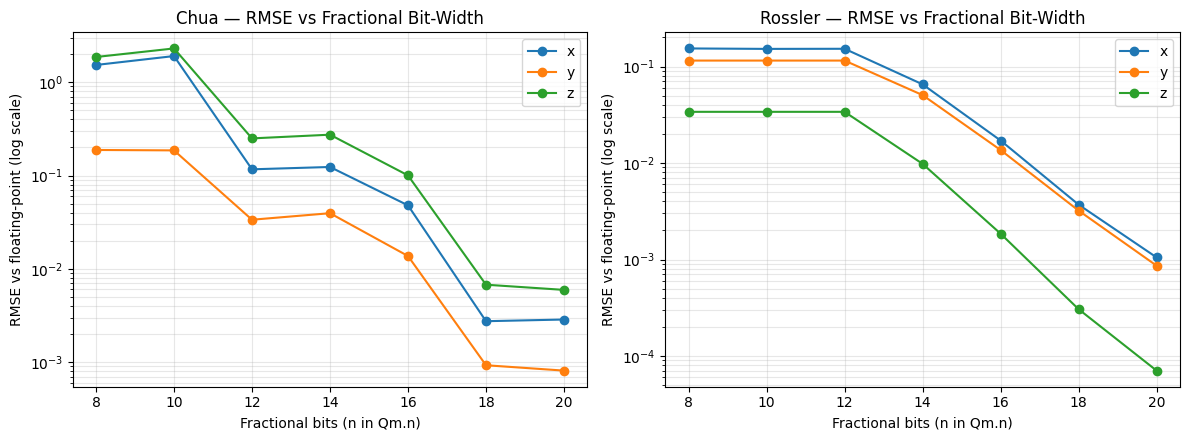

In [6]:
# RMSE vs fractional bit-width (log scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, system in zip(axes, ["chua", "rossler"]):
    fbs = [r["frac_bits"] for r in results[system]]
    for i, label in enumerate(["x", "y", "z"]):
        rmse_i = [r["rmse"][i] for r in results[system]]
        ax.semilogy(fbs, rmse_i, "o-", label=label)
    ax.set_xlabel("Fractional bits (n in Qm.n)")
    ax.set_ylabel("RMSE vs floating-point (log scale)")
    ax.set_title(f"{system.capitalize()} — RMSE vs Fractional Bit-Width")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


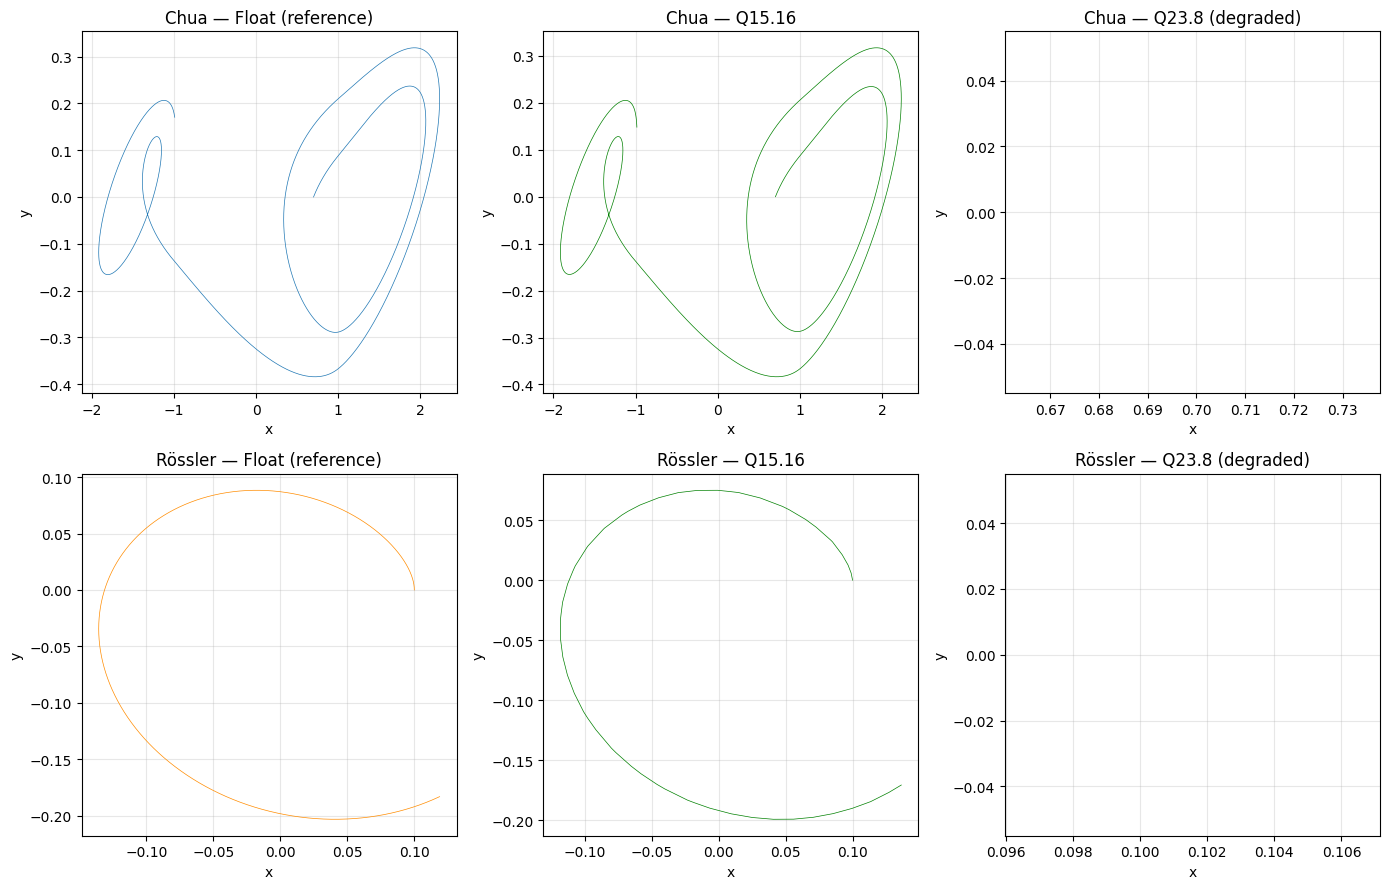

In [7]:
# Phase-portrait comparison: float vs Q15.16 vs Q23.8 (degraded)
chua_q16 = next(r for r in results["chua"] if r["frac_bits"] == 16)
chua_q8 = next(r for r in results["chua"] if r["frac_bits"] == 8)
rossler_q16 = next(r for r in results["rossler"] if r["frac_bits"] == 16)
rossler_q8 = next(r for r in results["rossler"] if r["frac_bits"] == 8)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0,0].plot(chua_float[:,0], chua_float[:,1], lw=0.5)
axes[0,0].set_title("Chua — Float (reference)")
axes[0,1].plot(chua_q16["traj"][:,0], chua_q16["traj"][:,1], lw=0.5, color="green")
axes[0,1].set_title(f"Chua — {chua_q16['qformat']}")
axes[0,2].plot(chua_q8["traj"][:,0], chua_q8["traj"][:,1], lw=0.5, color="red")
axes[0,2].set_title(f"Chua — {chua_q8['qformat']} (degraded)")

axes[1,0].plot(rossler_float[:,0], rossler_float[:,1], lw=0.5, color="darkorange")
axes[1,0].set_title("Rössler — Float (reference)")
axes[1,1].plot(rossler_q16["traj"][:,0], rossler_q16["traj"][:,1], lw=0.5, color="green")
axes[1,1].set_title(f"Rössler — {rossler_q16['qformat']}")
axes[1,2].plot(rossler_q8["traj"][:,0], rossler_q8["traj"][:,1], lw=0.5, color="red")
axes[1,2].set_title(f"Rössler — {rossler_q8['qformat']} (degraded)")

for ax in axes.flat:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


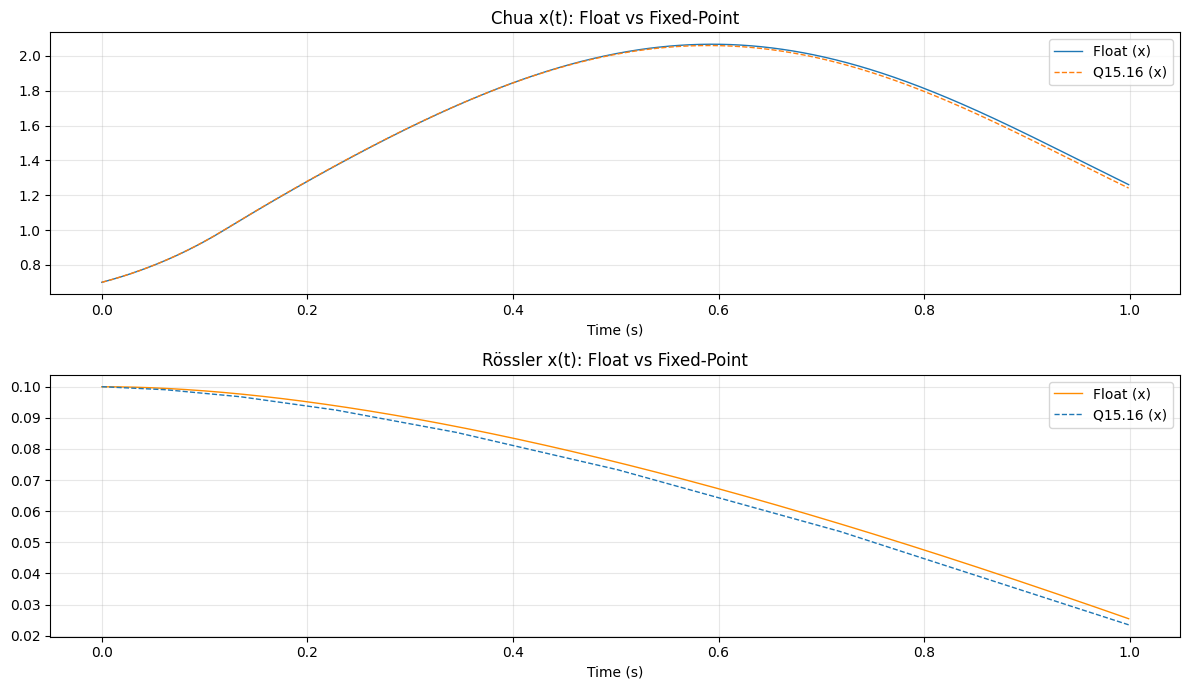

In [8]:
# Time-series overlay: float vs chosen Q15.16 fixed-point
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(t[:1000], chua_float[:1000, 0], label="Float (x)", lw=1)
axes[0].plot(t[:1000], chua_q16["traj"][:1000, 0], "--", label=f"{chua_q16['qformat']} (x)", lw=1)
axes[0].set_title("Chua x(t): Float vs Fixed-Point")
axes[0].set_xlabel("Time (s)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t[:1000], rossler_float[:1000, 0], label="Float (x)", lw=1, color="darkorange")
axes[1].plot(t[:1000], rossler_q16["traj"][:1000, 0], "--", label=f"{rossler_q16['qformat']} (x)", lw=1)
axes[1].set_title("Rössler x(t): Float vs Fixed-Point")
axes[1].set_xlabel("Time (s)"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Discussion and Recommended Format

### Observations from the sweep

- **Q23.8 / Q21.10 (8–10 fractional bits):** The fixed-point trajectories **collapse to a fixed
  point** — the chaotic attractor is destroyed entirely. Correlation with the float reference is
  `NaN` because the fixed-point output becomes constant (zero variance). This demonstrates the
  high sensitivity of chaotic systems to numerical precision: too few fractional bits causes the
  Chua diode's piecewise terms (and the Rössler product term $z(x-c)$) to round to zero or to
  values that drive the system into a stable fixed point instead of a chaotic orbit.

- **Q19.12 – Q17.14 (12–14 fractional bits):** The Chua attractor is recovered (correlation
  ~0.97–0.99), but the Rössler system is still significantly degraded (correlation as low as
  ~0.84 for x). Rössler's $z(x-c)$ term involves a large constant ($c=5.7$) multiplied by a
  fixed-point variable, which is more sensitive to the integer/fractional bit split.

- **Q15.16 (16 fractional bits) — matches the thesis-specified Q16.16 format:** Both systems
  achieve correlation > 0.99 across all three state variables, with RMSE on the order of
  $10^{-2}$. The phase portraits and time series are visually indistinguishable from the
  floating-point reference at this resolution.

- **Q13.18 / Q11.20 (18–20 fractional bits):** Marginal further improvement (correlation
  > 0.999, RMSE ~$10^{-3}$), at the cost of reduced integer range (max magnitude ≈ ±2048 and
  ±512 respectively). Since the Chua/Rössler state variables in this normalized parameter set
  stay within roughly ±3, this reduced range is still sufficient — making Q13.18 a viable
  higher-precision alternative if more headroom for accumulation error is desired.

### Recommended format: **Q16.16 (32-bit word, 16 integer bits, 16 fractional bits)**

This format is selected because it:

1. **Faithfully reproduces the chaotic attractor** for both Chua and Rössler (correlation > 0.99,
   visually matching phase portraits and time series)
2. **Provides ample dynamic range** (±32768) — comfortably covers the normalized state variable
   ranges (~±3) plus headroom for parameter products and intermediate terms in the Euler update
   without overflow
3. **Aligns with standard 32-bit FPGA register and DSP slice widths** on the Zynq-7020, simplifying
   AXI-Lite register mapping (each state/parameter fits exactly in one 32-bit register)
4. **Matches the format specified in the thesis design** (Q16.16 fixed-point arithmetic), keeping
   the HLS/VHDL implementation consistent with the documented mathematical model

### Effect on system behavior summary

| Format | Chua attractor preserved? | Rössler attractor preserved? | Notes |
|---|---|---|---|
| Q23.8 / Q21.10 | ✗ (collapses to fixed point) | ✗ (collapses to fixed point) | Unusable |
| Q19.12 / Q17.14 | ~ (partial degradation) | ✗ (significant degradation) | Borderline |
| **Q15.16 (Q16.16)** | ✓ | ✓ | **Recommended** |
| Q13.18 / Q11.20 | ✓ (higher fidelity) | ✓ (higher fidelity) | Reduced range, marginal gain |

This analysis directly informs the HLS/VHDL fixed-point type definitions
(`ap_fixed<32,16>` in Vitis HLS, equivalent to Q16.16) used in the FPGA implementation of the
Chua and Rössler oscillators (SO2).
